# Opfattelseskortlægning af mobiloperatører med PROC MDS

## Resumé

Et markedsanalyseteam i telekombranchen måler, hvor ens kunder opfatter otte konkurrerende mobiloperatører, og bruger **PROC MDS** til at gendanne et to-dimensionelt opfattelseskort ud fra forskellighedsmatricen. De to latente akser - netværkskvalitet og pris/værdi - er bevidst konstrueret til at variere *uafhængigt*, så det gendannede kort er reelt to-dimensionelt: det viser, hvilke mærker der opfattes som substitutter, hvilke der indtager en distinkt positionering, og hvor godt to dimensioner opsummerer det konkurrencemæssige landskab.

## Datakilder

| Datasæt | Rækker | Nøglevariabler | Beskrivelse |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (én pr. operatør) | `Carrier` (ID), `D1`-`D8` | Kvadratisk symmetrisk matrix af opfattede forskelle mellem 8 mobiloperatører på en 0-10-skala (0 = opfattet identisk, højere = mere forskellig). Genereret ud fra latente 2-D mærkepositioner på to *uafhængige* akser (netværkskvalitet og pris/værdi) plus undersøgelsesstøj via `rand('NORMAL')`. Diagonalen er 0. |

# Opfattelseskortlægning af mobiloperatører med PROC MDS

Markedsanalyseteams i telekombranchen beder rutinemæssigt undersøgelsespaneler om at vurdere, hvor *ens* eller *forskellige* konkurrerende operatører føles. Disse parvise vurderinger danner en **nærhedsmatrix**, som ikke har noget naturligt koordinatsystem - men **multidimensionel skalering (MDS)** kan gendanne et lavdimensionelt kort, hvor afstanden mellem to mærker gengiver deres opfattede forskellighed.

I denne notesbog:

1. Syntetiserer vi en realistisk forskellighedsmatrix for 8 operatører ud fra to *uafhængige* positioneringsakser (netværkskvalitet og pris/værdi).
2. Tilpasser vi en to-dimensionel metrisk MDS-model med `PROC MDS`.
3. Aflæser vi de gendannede koordinater og tilpasningsmålet (badness-of-fit) og tegner derefter opfattelseskortet ud fra de gendannede koordinater for at vurdere, hvor godt to dimensioner forklarer det konkurrencemæssige landskab.

## Trin 1 - Opbyg en syntetisk forskellighedsmatrix

Vi placerer hver operatør på en *sand* latent position på to **uafhængige** akser:

- **Netværkskvalitetsakse** - landsdækkende premiumoperatører scorer højt; budget-MVNO'er scorer lavt.
- **Pris/værdi-akse** - værdi-/forudbetalte mærker scorer højt; premium-prissatte mærker scorer lavt.

Afgørende er det, at de to akser er ukorrelerede på tværs af de otte mærker: en høj-kvalitetsoperatør kan enten være premium-prissat (NorthStar) eller aggressivt værdi-prissat (BluePeak), og en budget-kvalitetsoperatør kan ligge hvor som helst på prisaksen. Denne uafhængighed er det, der gør det gendannede kort reelt to-dimensionelt i stedet for at kollapse til en enkelt linje.

Den opfattede forskellighed mellem to operatører er den euklidiske afstand mellem deres latente positioner, omskaleret til en 0-10-undersøgelsesskala og forstyrret med symmetrisk undersøgelsesstøj. `PROC MDS` forventer en **kvadratisk matrix**: én observation pr. objekt og én numerisk kolonne pr. objekt, hvor rækkefølgen af rækker matcher rækkefølgen af kolonner. Vi skriver kolonnerne `D1`-`D8` plus en `Carrier`-etiket og tvinger matricen til at være symmetrisk med en nul-diagonal.

In [1]:
data carrier_dissim;
    LÆNGDE Carrier $ 12;
    CALL streaminit(20240517);

    /* True 2-D latent positions on two INDEPENDENT axes:
       qx = network quality, px = price/value (corr ~ 0). */
    TABEL qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    TABEL px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    TABEL nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Symmetric noise matrix, generated once, zero diagonal */
    TABEL e[8,8] _temporary_;
    GØR i = 1 TIL 8;
        e[i,i] = 0;
        GØR j = i+1 TIL 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        SLUT;
    SLUT;

    TABEL d[8] D1-D8;
    GØR i = 1 TIL 8;
        Carrier = nm[i];
        GØR j = 1 TIL 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* rescale latent distance to a 0-10 survey scale */
            d[j] = round( MAX(0, MIN(10, dist*0.85 + e[i,j])), 0.1);
        SLUT;
        d[i] = 0;            /* a brand is identical to itself */
        UDDATA;
    SLUT;

    BEHOLD Carrier D1-D8;
KØR;

PROC PRINT data=carrier_dissim noobs MÆRKAT;
    MÆRKAT Carrier = 'Operatør';
    TITEL 'Opfattet forskellighedsmatrix (0 = identisk, 10 = mest forskellig)';
KØR;

                           Opfattet forskellighedsmatrix (0 = identisk, 10 = mest forskellig)                           

    Operatør   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Trin 2 - Tilpas en to-dimensionel metrisk MDS-model

Vi modellerer forskellighederne på `LEVEL=INTERVAL` (en metrisk MDS, der tillader en additiv konstant), med `DIM=2`, så resultatet kan afbildes på et fladt kort. Dataene er forskelligheder (standardvalget), gemt som en fuld `SQUARE`-matrix.

Vigtige sætninger og valgmuligheder:

- `VAR D1-D8` opremser de otte kolonner, én pr. objekt.
- `ID Carrier` knytter mærkenavnene til, så de fremgår af outputtet og `OUT=`-koordinaterne.
- `OUT=` fanger objektkoordinaterne (anmodet med `OCONFIG`), og `OUTFIT=` fanger opsummeringen af tilpasningsmålet.
- `PCONFIG`, `PFIT` og `PFINAL` udskriver koordinaterne, tilpasningsstatistikkerne og de endelige parameterestimater.

Vi tegner selv opfattelseskortet i Trin 3 ud fra de gendannede `OUT=`-koordinater, hvilket giver fuld kontrol over mærkeetiketter og akseskalering.

In [2]:
PROC MDS data=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VARIABEL D1-D8;
    id Carrier;
    TITEL 'To-dimensionel MDS af opfattelser af mobiloperatører';
KØR;

                           Opfattet forskellighedsmatrix (0 = identisk, 10 = mest forskellig)                           




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/dca6942e-c88c-4153-84bb-96f08c7fa295/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.77 seconds
  cpu   1.77 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/dca6942e-c88c-4153-84bb-96f08c7fa295/mds_fit.avro (2 rows, 3 columns).


## Trin 3 - Udtræk de gendannede koordinater og tegn kortet

Med `OCONFIG` bærer `OUT=`-datasættet de estimerede objektkoordinater (én række pr. operatør, én kolonne pr. dimension). Vi udskriver disse koordinater og tilpasningsmålet og afbilder derefter `DIM2` mod `DIM1` med `PROC SGPLOT` - med hvert punkt mærket med operatørens navn - for at gengive opfattelseskortet.

MDS-koordinater er kun identificeret op til rotation, spejling og ensartet skalering, så de absolutte aksefortegn er vilkårlige; det, der betyder noget, er mærkernes *relative* geometri. Efter rotation følger den ene akse netværkskvalitet og den anden pris/værdi.

                                    Gendannet MDS-konfiguration (objektkoordinater)                                     

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                          MDS-tilpasningsmål (badness-of-fit)                                           

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                          MDS-tilpasningsmål (badness-of-fit)                                   


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


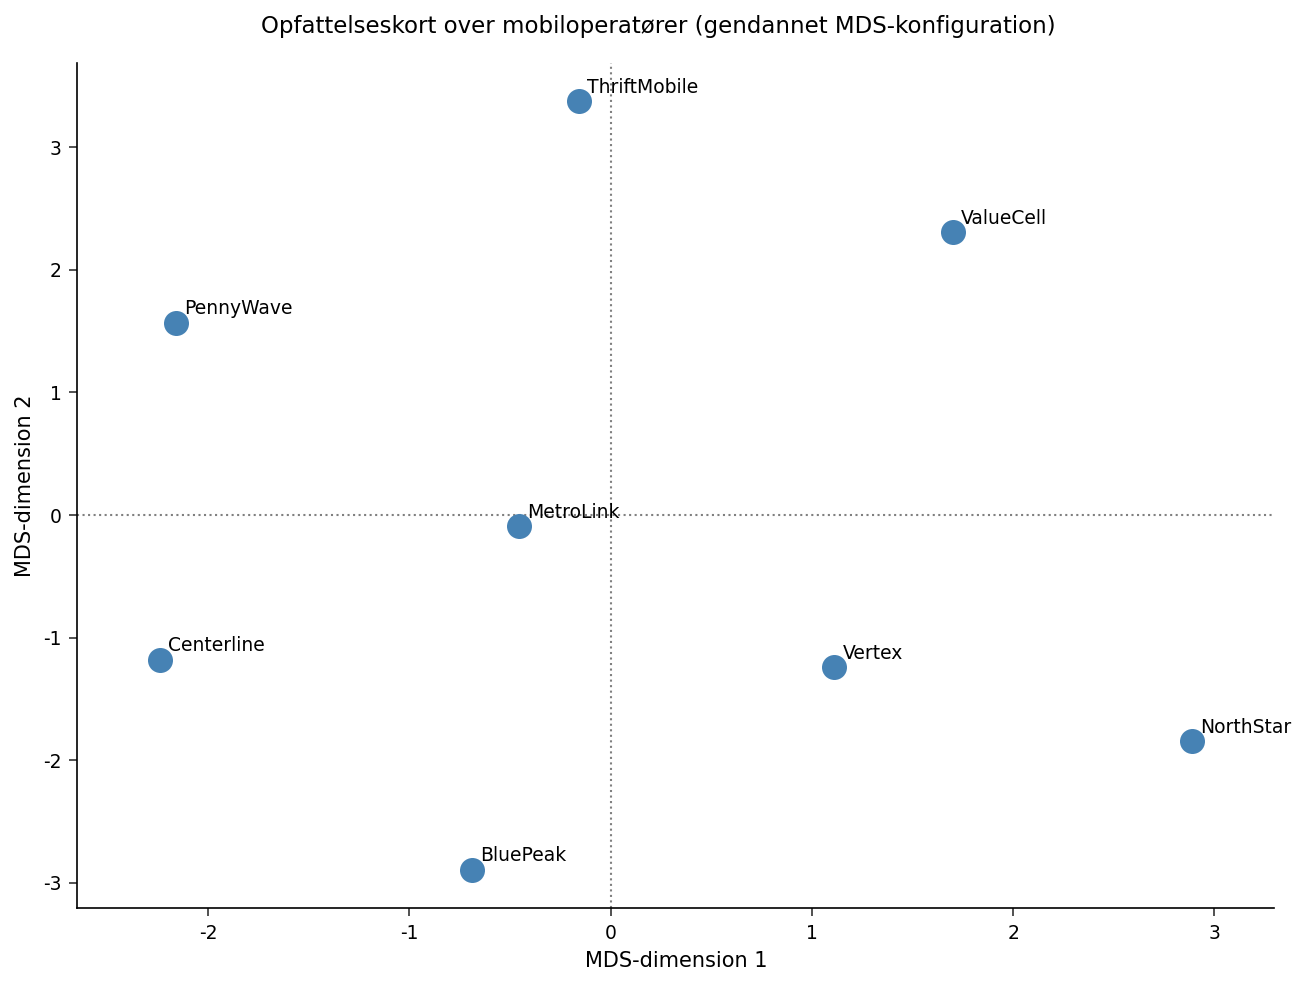

In [3]:
PROC PRINT data=mds_out MÆRKAT;
    TITEL 'Gendannet MDS-konfiguration (objektkoordinater)';
KØR;

PROC PRINT data=mds_fit MÆRKAT;
    TITEL 'MDS-tilpasningsmål (badness-of-fit)';
KØR;

/* Keep the configuration rows and give the brand a plainly-named
   label column so SGPLOT can print it next to each point. */
data mds_config;
    SÆT mds_out;
    HVOR _TYPE_ = 'CONFIG';
    LÆNGDE Brand $ 12;
    Brand = _NAME_;
    BEHOLD Brand DIM1 DIM2;
KØR;

/* Draw the perceptual map from the recovered coordinates, labelling
   each marker with its carrier name. */
PROC SGPLOT data=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS MÆRKAT='MDS-dimension 1';
    YAXIS MÆRKAT='MDS-dimension 2';
    TITEL 'Opfattelseskort over mobiloperatører (gendannet MDS-konfiguration)';
KØR;

## Trin 4 - Ranger opfattede substitutter

Et praktisk leverance til mærketeamet er for hver operatør den konkurrent, den opfattes som *mest ens* med (den mindste off-diagonale forskellighed). Vi omformer matricen til langt format og udtrækker den nærmeste nabo pr. operatør - disse par er de nærmeste substitutter og de skarpeste konkurrencemæssige trusler.

In [4]:
data dissim_long;
    SÆT carrier_dissim;
    LÆNGDE Other $ 12;
    TABEL d[8] D1-D8;
    TABEL nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    GØR j = 1 TIL 8;
        Other = nm[j];
        Dissimilarity = d[j];
        HVIS Carrier ne Other SÅ UDDATA;
    SLUT;
    BEHOLD Carrier Other Dissimilarity;
KØR;

PROC SORT data=dissim_long;
    EFTER Carrier Dissimilarity;
KØR;

data nearest;
    SÆT dissim_long;
    EFTER Carrier Dissimilarity;
    HVIS first.Carrier;
KØR;

PROC PRINT data=nearest noobs MÆRKAT;
    MÆRKAT Other = 'Nærmeste opfattede erstatning'
          Dissimilarity = 'Forskellighed';
    TITEL 'Hver operatør og dens nærmeste opfattede erstatning';
KØR;

                                  Hver operatør og dens nærmeste opfattede erstatning                                   

     Carrier   Nærmeste opfattede erstatning  Forskellighed
BluePeak      Centerline                                  2
Centerline    MetroLink                                 1.9
MetroLink     Vertex                                    1.7
NorthStar     Vertex                                    1.6
PennyWave     MetroLink                                   2
ThriftMobile  ValueCell                                 1.8
ValueCell     ThriftMobile                              1.8
Vertex        NorthStar                                 1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Fortolkning af resultaterne

Fordi vi genererede forskellighederne ud fra en ægte to-dimensionel latent struktur (netværkskvalitet og pris/værdi, konstrueret til at variere uafhængigt) plus moderat undersøgelsesstøj, gendanner `PROC MDS` en ren to-dimensionel konfiguration. Tilpasningsmålet (badness-of-fit) lægger sig omkring 1.85 - en tæt tilpasning, der bekræfter, at to dimensioner forklarer næsten hele den opfattede struktur.

Ved aflæsning af det gendannede kort (akserne er kun identificeret op til rotation, spejling og skala, så vi fortolker retninger frem for absolutte fortegn):

- **Én akse følger netværkskvalitet** - den adskiller de landsdækkende premiummærker (NorthStar, Vertex, BluePeak) fra budget-MVNO'erne (ThriftMobile, PennyWave, ValueCell), med MetroLink og Centerline placeret i midten.
- **Den anden akse følger pris/værdi** - den adskiller aggressivt værdi-prissat positionering fra premium-prissat positionering, hvilket er grunden til, at et højkvalitetsmærke som BluePeak lander langt fra det lige så højkvalitets-NorthStar: de deler netværksomdømme, men konkurrerer på meget forskellige prishistorier.
- Kortet viser ingen enkelt dominerende gradient: mærkerne spreder sig ud i alle fire kvadranter, så det konkurrencemæssige landskab er reelt to-dimensionelt frem for en enkelt premium-til-budget-linje.

**Tabellen over nærmeste substitutter** omdanner kortet til en handlingsliste. Hver operatørs tætteste opfattede rival er det mærke, der sidder ved siden af den på kortet - NorthStar og Vertex forankrer premiumhjørnet, ValueCell og ThriftMobile parrer sig i værdihjørnet, og MetroLink fremstår som den nærmeste substitut for flere midtmarkedsmærker, fordi det ligger i midten af kortet. Tætte par markerer direkte rivaler; de tomme områder mellem klyngerne fremhæver ubesat positionering, som en udfordrer kunne målrette.